In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

In [2]:
treino_df = pd.read_csv('train.csv')
treino_df.sample(5)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
432035,432035,Female,0,No,No,14,No,No phone service,DSL,Yes,...,No,Yes,No,No,One year,Yes,Mailed check,35.75,1398.90,No
266884,266884,Male,0,No,No,46,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),25.05,1563.85,No
184744,184744,Female,0,No,No,1,Yes,No,DSL,Yes,...,Yes,No,No,No,Month-to-month,No,Mailed check,56.30,56.30,Yes
364195,364195,Female,1,Yes,No,44,Yes,No,DSL,Yes,...,No,Yes,No,Yes,One year,Yes,Mailed check,71.00,2774.35,No
374906,374906,Male,0,No,No,15,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,No,Mailed check,25.15,593.75,No


In [ ]:
treino_df["Churn"] = treino_df["Churn"].apply(lambda x: 1 if x == "Yes" else 0)
treino_df["Partner"] = treino_df["Partner"].apply(lambda x: 1 if x == "Yes" else 0)
treino_df["Dependents"] = treino_df["Dependents"].apply(lambda x: 1 if x == "Yes" else 0)
treino_df["PhoneService"] = treino_df["PhoneService"].apply(lambda x: 1 if x == "Yes" else 0)
treino_df["MultipleLines"] = treino_df["MultipleLines"].apply(lambda x: 1 if x == "Yes" else 0)
treino_df["OnlineSecurity"] = treino_df["OnlineSecurity"].apply(lambda x: 1 if x == "Yes" else 0)
treino_df["OnlineBackup"] = treino_df["OnlineBackup"].apply(lambda x: 1 if x == "Yes" else 0)
treino_df["DeviceProtection"] = treino_df["DeviceProtection"].apply(lambda x: 1 if x == "Yes" else 0)
treino_df["TechSupport"] = treino_df["TechSupport"].apply(lambda x: 1 if x == "Yes" else 0)
treino_df["StreamingTV"] = treino_df["StreamingTV"].apply(lambda x: 1 if x == "Yes" else 0)
treino_df["StreamingMovies"] = treino_df["StreamingMovies"].apply(lambda x: 1 if x == "Yes" else 0)
treino_df["PaperlessBilling"] = treino_df["PaperlessBilling"].apply(lambda x  : 1 if x == "Yes" else 0)
treino_df["SeniorCitizen"] = treino_df["SeniorCitizen"].apply(lambda x: 1 if x == 1 else 0)
treino_df = treino_df.drop(columns=["id"])
treino_df = pd.get_dummies(treino_df, columns=["Contract", "InternetService", "PaymentMethod"], drop_first=True)

In [4]:
treino_df.sample(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn
301978,Male,0,1,1,67,1,1,1,1,1,0,0,0,0,87.10,5598.0,0
541154,Male,0,1,1,12,1,0,0,0,0,0,0,0,0,19.95,264.8,0
361384,Female,0,1,0,71,1,0,0,0,0,0,0,0,0,20.15,1356.4,0
31534,Female,0,1,0,58,1,1,0,0,0,0,1,1,1,95.25,6152.3,1
246991,Female,1,1,0,56,1,1,0,1,0,0,0,1,1,91.55,5154.6,0


In [5]:
n1 = treino_df[treino_df["Churn"] == 1].value_counts()
n2 = treino_df[treino_df["Churn"] == 0].value_counts()
print(f"Churn = 1: {n1.sum()}")
print(f"Churn = 0: {n2.sum()}")

Churn = 1: 133817
Churn = 0: 460377


In [6]:
df = treino_df

In [7]:
X = df.drop(columns=["Churn", "gender"])
y = df["Churn"]


In [8]:
xtreino, xteste, ytreino, yteste = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Calcular pesos para balancear classes
class_weights = compute_class_weight('balanced', classes=np.unique(ytreino), y=ytreino)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"Distribuição - Churn=0: {(ytreino==0).sum()} | Churn=1: {(ytreino==1).sum()}")
print(f"Pesos das classes: {class_weight_dict}")

Distribuição - Churn=0: 368301 | Churn=1: 107054
Pesos das classes: {0: np.float64(0.6453349298535709), 1: np.float64(2.220164589833168)}


In [9]:
modelo = RandomForestClassifier(
    n_estimators=20,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

In [10]:
modelo.fit(xtreino, ytreino)

previsao = modelo.predict(xteste)
previsao_proba = modelo.predict_proba(xteste)

# Calcular métricas de classificação
accuracy = accuracy_score(yteste, previsao)
precision = precision_score(yteste, previsao)
recall = recall_score(yteste, previsao)
f1 = f1_score(yteste, previsao)

In [11]:
print("\n" + "="*60)
print("RESULTADOS")
print("="*60)
print(f"Acurácia:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precisão: {precision:.4f}")
print(f"Recall:   {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Matriz de confusão
cm = confusion_matrix(yteste, previsao)
tn, fp, fn, tp = cm.ravel()
print(f"\nMatriz de Confusão:")
print(f"Verdadeiros Negativos (TN): {tn}")
print(f"Falsos Positivos (FP):      {fp}")
print(f"Falsos Negativos (FN):      {fn}")
print(f"Verdadeiros Positivos (TP): {tp}")
print("="*60)


RESULTADOS
Acurácia:  0.8232 (82.32%)
Precisão: 0.5751
Recall:   0.8233
F1-Score: 0.6772

Matriz de Confusão:
Verdadeiros Negativos (TN): 75796
Falsos Positivos (FP):      16280
Falsos Negativos (FN):      4728
Verdadeiros Positivos (TP): 22035


In [12]:
# Mostrar comparação
df_comparacao = pd.DataFrame({
    'Real': yteste.reset_index(drop=True),
    'Previsao': previsao,
    'Probabilidade_Churn': previsao_proba[:, 1],
    'Correto': previsao == yteste.values
})


print(f"\nTotal de previsões corretas: {df_comparacao['Correto'].sum()} / {len(df_comparacao)}")


Total de previsões corretas: 97831 / 118839


In [13]:
acuracy = modelo.score(xteste, yteste)
print(f"\nAcurácia do modelo: {acuracy:.4f}")


Acurácia do modelo: 0.8232


In [15]:
print("\n" + "="*60)
print("RESUMO FINAL DO MODELO")
print("="*60)
print(f"Acurácia:           {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precisão:           {precision:.4f}")
print(f"Recall:             {recall:.4f}")
print(f"F1-Score (teste):   {f1:.4f}")
#print(f"F1-Score (CV 5x):   {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"\nTotal de acertos:   {df_comparacao['Correto'].sum()} / {len(df_comparacao)}")
print("="*60)


RESUMO FINAL DO MODELO
Acurácia:           0.8232 (82.32%)
Precisão:           0.5751
Recall:             0.8233
F1-Score (teste):   0.6772

Total de acertos:   97831 / 118839


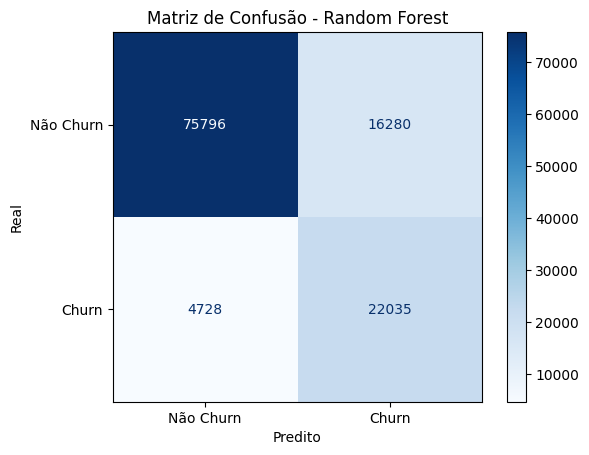

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(yteste, previsao)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Não Churn", "Churn"])

disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusão - Random Forest")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

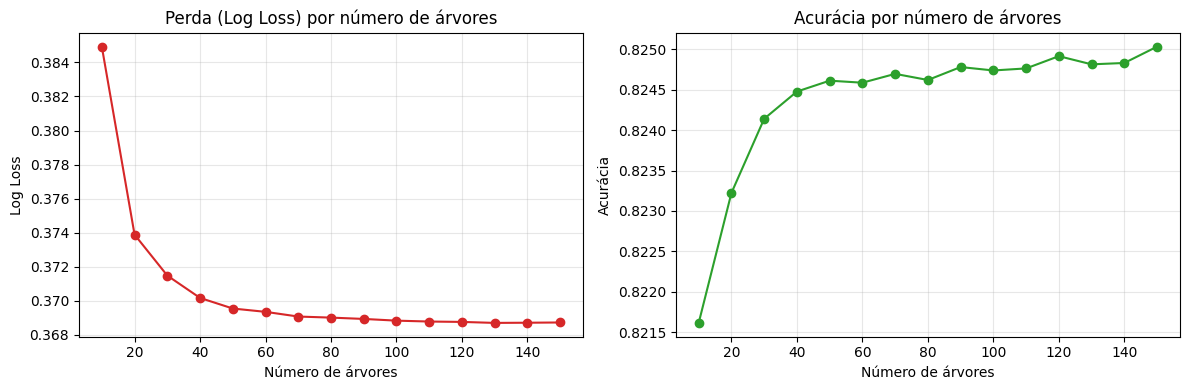

In [17]:
from sklearn.metrics import log_loss

n_steps = list(range(10, 151, 10))
losses = []
accuracies = []

for n in n_steps:
    rf_iter = RandomForestClassifier(
        n_estimators=n,
        max_depth=20,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    rf_iter.fit(xtreino, ytreino)
    probas = rf_iter.predict_proba(xteste)
    losses.append(log_loss(yteste, probas))
    accuracies.append(accuracy_score(yteste, rf_iter.predict(xteste)))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(n_steps, losses, marker='o', color='tab:red')
plt.title('Perda (Log Loss) por número de árvores')
plt.xlabel('Número de árvores')
plt.ylabel('Log Loss')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(n_steps, accuracies, marker='o', color='tab:green')
plt.title('Acurácia por número de árvores')
plt.xlabel('Número de árvores')
plt.ylabel('Acurácia')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()